In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'
results_path = project_path + '/results'

print("SERIAL 19 loaded successfully.")
print("Project folder exists:", os.path.exists(project_path))
print("Results folder exists:", os.path.exists(results_path))

Mounted at /content/drive
SERIAL 19 loaded successfully.
Project folder exists: True
Results folder exists: True


#Now we'll load the results from the four previous experiments.

In [2]:
global_result = pd.read_csv(
    results_path + "/global_zscore_evaluation_A8.csv"
)

rolling_result = pd.read_csv(
    results_path + "/statistical_methods_comparison_A8.csv"
)

isolation_result = pd.read_csv(
    results_path + "/isolation_forest_evaluation_A8.csv"
)

svm_result = pd.read_csv(
    results_path + "/one_class_svm_evaluation_A8.csv"
)

print("Global Z-score:")
display(global_result)

print("Statistical comparison:")
display(rolling_result)

print("Isolation Forest:")
display(isolation_result)

print("One-Class SVM:")
display(svm_result)

Global Z-score:


,channel,method,threshold,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
0,A-8,Global Z-score,±3,0.0,0.0,0.0,0.0,1.0,4569,0,3806,0


Statistical comparison:


,channel,method,threshold,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
0,A-8,Global Z-score,±3,0.000000,0.000000,0.00000,0.000000,1.000000,4569,0,3806,0
1,A-8,Rolling Z-score,±3,0.581921,0.027063,0.05172,0.016196,0.972937,4495,74,3703,103


Isolation Forest:


,channel,method,contamination,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
0,A-8,Isolation Forest,auto,0.454448,1.0,0.624908,1.0,0.0,0,4569,0,3806


One-Class SVM:


,channel,method,kernel,gamma,nu,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
0,A-8,One-Class SVM,rbf,scale,0.05,0.35511,0.655544,0.460672,0.991683,0.344456,38,4531,1311,2495


#Create one clean comparison table

In [3]:
rolling_only = rolling_result[
    rolling_result["method"] == "Rolling Z-score"
].copy()

comparison = pd.concat(
    [
        global_result,
        rolling_only,
        isolation_result,
        svm_result
    ],
    ignore_index=True
)

comparison_table = comparison[
    [
        "channel",
        "method",
        "precision",
        "recall",
        "f1_score",
        "false_positive_rate",
        "false_negative_rate"
    ]
].copy()

display(comparison_table)

,channel,method,precision,recall,f1_score,false_positive_rate,false_negative_rate
0,A-8,Global Z-score,0.000000,0.000000,0.000000,0.000000,1.000000
1,A-8,Rolling Z-score,0.581921,0.027063,0.051720,0.016196,0.972937
2,A-8,Isolation Forest,0.454448,1.000000,0.624908,1.000000,0.000000
3,A-8,One-Class SVM,0.355110,0.655544,0.460672,0.991683,0.344456


The important pattern is:

Global Z-score: completely misses the contextual anomaly.

Rolling Z-score: has relatively good precision, but detects very few anomalies (2.7% recall).

Isolation Forest: detects 100% of anomalies, but also marks 100% of normal points as anomalies.

One-Class SVM: detects about 65.6% of anomalies, but has 99.2% false positives.

So none of the four is suitable as-is for practical detection on A-8.

#A simple F1-score comparison.

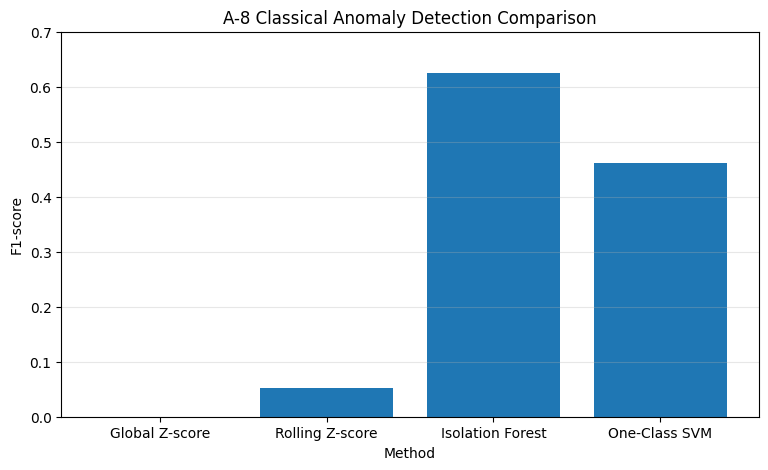

In [4]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_table["method"],
    comparison_table["f1_score"]
)

plt.title("A-8 Classical Anomaly Detection Comparison")
plt.xlabel("Method")
plt.ylabel("F1-score")
plt.ylim(0, 0.7)
plt.grid(axis="y", alpha=0.3)

plt.show()

On A-8, the classical machine-learning baselines achieved higher F1-scores than the statistical baselines, but both Isolation Forest and One-Class SVM produced extremely high false-positive rates. Therefore, higher F1 alone does not indicate practical anomaly-detection performance. These results motivate the use of temporal and reconstruction-based approaches.

###Now let's save this comparison as a CSV so we have a permanent record

In [5]:
comparison_table.to_csv(
    results_path + "/classical_methods_comparison_A8.csv",
    index=False
)

print("Classical methods comparison saved successfully.")
print(results_path + "/classical_methods_comparison_A8.csv")

Classical methods comparison saved successfully.
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/classical_methods_comparison_A8.csv


#git commit

In [6]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (27/27), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/13_evaluate_global_zscore.ipynb
	modified:   notebooks/14_rolling_zscore.ipynb
	modified:   notebooks/15_compare_statistical_methods.ipynb
	modified:   notebooks/16_isolation_forest.ipynb
	modified:   notebooks/17_evaluate_isolation_forest.ipynb
	modified:   notebooks/18_one_class_svm.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/19_compare_classical_methods.ipynb
	results/classical_methods_comparison_A8.csv

no changes added to commit (use "git add" and/or "git commit -a")


In [7]:
!git add notebooks/19_compare_classical_methods.ipynb results/classical_methods_comparison_A8.csv

!git commit -m "Complete SERIAL 19 classical methods comparison"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@53a1aaf0f50d.(none)')


In [8]:
!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

!git commit -m "Complete SERIAL 19 classical methods comparison"

[main 18ca216] Complete SERIAL 19 classical methods comparison
 2 files changed, 6 insertions(+)
 create mode 100644 notebooks/19_compare_classical_methods.ipynb
 create mode 100644 results/classical_methods_comparison_A8.csv


In [9]:
!git push origin main


Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 29.09 KiB | 3.23 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   d4d6106..18ca216  main -> main
